In [14]:
import numpy as np

geno = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/all_individuals.npy")
recon = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/vae/recon_all.npy")

# If geno is in {0,1,2}, scale to [0,1] to match recon:
geno_scaled = geno / 2.0

mse = np.mean((geno_scaled - recon)**2)
mae = np.mean(np.abs(geno_scaled - recon))

print("Per-entry MSE:", mse)
print("Per-entry MAE:", mae)


Per-entry MSE: 0.04994251
Per-entry MAE: 0.0845734


In [15]:
snp_means = geno_scaled.mean(axis=0, keepdims=True)
mse_baseline = np.mean((geno_scaled - snp_means)**2)
print("Baseline MSE:", mse_baseline)


Baseline MSE: 0.017931603


In [16]:
geno.shape

(1000, 10000)

In [12]:
# load the .trees sequence
import tskit
import numpy as np
ts = tskit.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/vae_sims/0/rep0/tree_sequence.trees")

In [13]:
G = ts.genotype_matrix()
G.shape

(677315, 2000)

In [14]:
biallelic = np.max(G, axis=1) <= 1

In [15]:
print(f'Number of non-biallelic variants: {G.shape[0] - biallelic.sum()}')

Number of non-biallelic variants: 1543


In [16]:
genotype_matrix = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/all_individuals.npy")

In [17]:
genotype_matrix.shape

(1000, 10000)

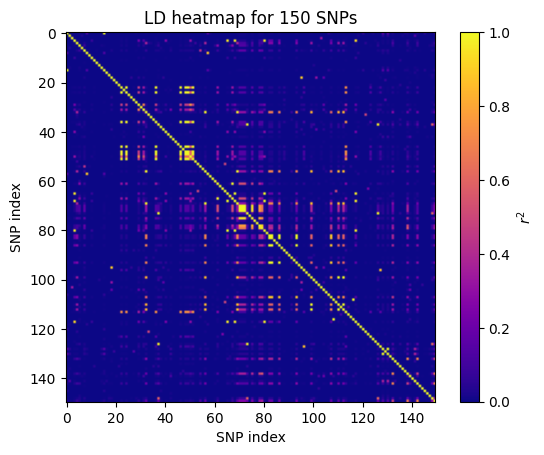

In [24]:
# Plot LD
import numpy as np

G = genotype_matrix.astype(np.float32)  # (1000, 10000), entries 0/1/2
n_snps = 150
start = (G.shape[1] - n_snps)//2
X = G[:, start:start+n_snps]

# mean-center and standardize each SNP
X = X - X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)
keep = (std[0] > 0)   # drop monomorphic
X = X[:, keep]
X = X / std[:, keep]

# correlation and r^2
R = (X.T @ X) / X.shape[0]
r2 = R * R
np.fill_diagonal(r2, 1.0)

r2.shape
import matplotlib.pyplot as plt
plt.imshow(r2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='$r^2$')
plt.title(F'LD heatmap for {n_snps} SNPs')
plt.xlabel('SNP index')
plt.ylabel('SNP index')
plt.show()


In [30]:
import numpy as np
import matplotlib.pyplot as plt

hap1 = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/hap1.npy')
hap2 = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/hap2.npy')

In [31]:
Hall = np.concatenate([hap1, hap2], axis=0)   # (2N, M)
p = Hall.mean(axis=0)
maf = np.minimum(p, 1 - p)

# remove monomorphic sites globally (across both haplotypes)
keep_poly = (p > 0) & (p < 1)

# optional: also remove very rare sites (helps LD / transformers)
maf_thresh_global = 0.01   # try 0.05 for clearer LD
keep_maf = maf >= maf_thresh_global

keep = keep_poly & keep_maf

hap1_f = hap1[:, keep]
hap2_f = hap2[:, keep]

print(f"Kept {hap1_f.shape[1]} / {hap1.shape[1]} SNPs (poly + MAF≥{maf_thresh_global})")


Kept 3084 / 10000 SNPs (poly + MAF≥0.01)


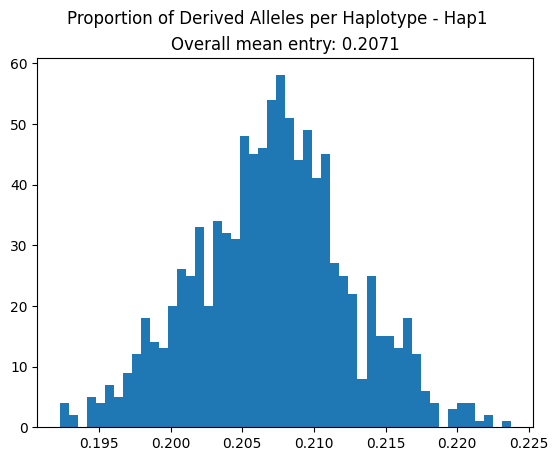

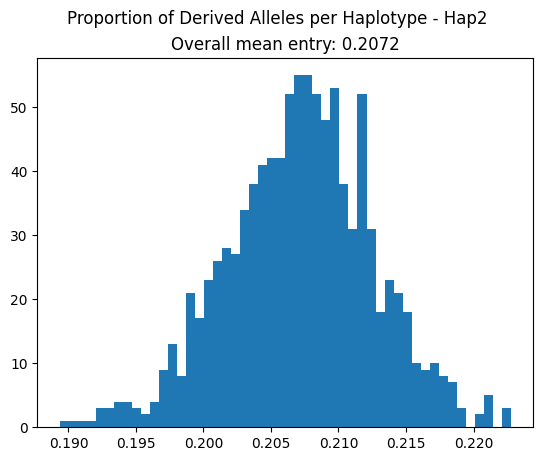

In [32]:
hap1_mean = hap1_f.mean(axis=1)
plt.figure()
plt.suptitle('Proportion of Derived Alleles per Haplotype - Hap1')
plt.title(f'Overall mean entry: {hap1_f.mean():.4f}')
plt.hist(hap1_mean, bins=50)
plt.show()

hap2_mean = hap2_f.mean(axis=1)
plt.figure()
plt.suptitle('Proportion of Derived Alleles per Haplotype - Hap2')
plt.title(f'Overall mean entry: {hap2_f.mean():.4f}')
plt.hist(hap2_mean, bins=50)
plt.show()


Window 2506:2906 | kept 400 SNPs after window MAF≥0.01
Plotted lags: 200 / 200


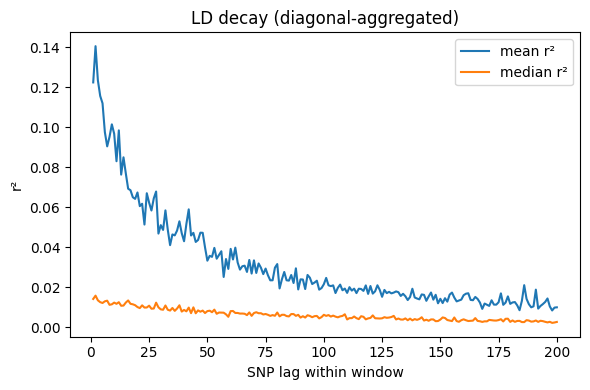

In [33]:
Hbase = np.concatenate([hap1_f, hap2_f], axis=0)  # (2N, M)

window_len = 400
start = np.random.randint(0, Hbase.shape[1] - window_len)
H = Hbase[:, start:start + window_len].astype(float)

# within-window MAF filter (optional; makes plots cleaner)
p = H.mean(axis=0)
maf = np.minimum(p, 1 - p)
maf_thresh_window = 0.01
keep_w = maf >= maf_thresh_window
H = H[:, keep_w]
print(f"Window {start}:{start+window_len} | kept {H.shape[1]} SNPs after window MAF≥{maf_thresh_window}")

H -= H.mean(axis=0)
corr = np.corrcoef(H, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
r2 = corr**2


# ---- LD decay by lag: use diagonal means/medians ----
M = r2.shape[0]
max_lag = min(200, M-1)
lags = np.arange(1, max_lag+1)

mean_r2 = np.array([np.mean(np.diag(r2, k=k)) for k in lags])
med_r2  = np.array([np.median(np.diag(r2, k=k)) for k in lags])
counts  = np.array([np.diag(r2, k=k).size for k in lags])

# only keep lags with enough pairs
min_pairs = 50
mask = counts >= min_pairs

print("Plotted lags:", mask.sum(), "/", mask.size)

plt.figure(figsize=(6,4))
plt.plot(lags[mask], mean_r2[mask], label="mean r²")
plt.plot(lags[mask], med_r2[mask],  label="median r²")
plt.xlabel("SNP lag within window")
plt.ylabel("r²")
plt.title("LD decay (diagonal-aggregated)")
plt.legend()
plt.tight_layout()
plt.show()


Kept 3084 / 3084 SNPs (MAF ≥ 0.01)


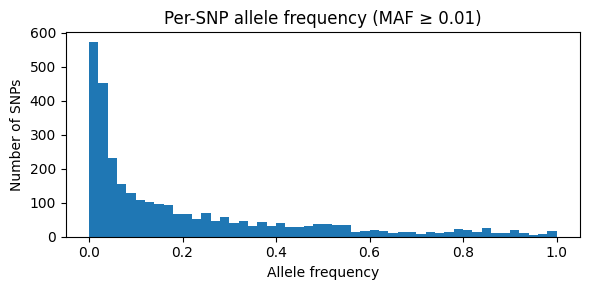

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# combine both haplotypes to get population allele frequency
Hbase = np.concatenate([hap1_f, hap2_f], axis=0)

p = Hbase.mean(axis=0)          # allele frequency across all chromosomes
maf = np.minimum(p, 1 - p)      # minor allele frequency

maf_thresh = 0.01
keep = maf >= maf_thresh

p_filt = p[keep]

print(f"Kept {p_filt.size} / {p.size} SNPs (MAF ≥ {maf_thresh})")

plt.figure(figsize=(6,3))
plt.hist(p_filt, bins=50, range=(0,1))
plt.xlabel("Allele frequency")
plt.ylabel("Number of SNPs")
plt.title(f"Per-SNP allele frequency (MAF ≥ {maf_thresh})")
plt.tight_layout()
plt.show()



In [35]:
import numpy as np

def ld_pair_stats(H, j, k):
    x = H[:, j].astype(float)
    y = H[:, k].astype(float)
    pA, pB = x.mean(), y.mean()
    pAB = (x*y).mean()
    D = pAB - pA*pB
    denom = pA*(1-pA)*pB*(1-pB)
    if denom <= 0:
        return pA, pB, pAB, D, np.nan, np.nan
    r = D / np.sqrt(denom)
    return pA, pB, pAB, D, r, r*r

# choose two SNPs with decent MAF (global)
p = Hbase.mean(axis=0)
maf = np.minimum(p, 1-p)
good = np.where(maf >= 0.05)[0]   # try 0.01 if too strict

j, k = good[0], good[1]
print("Chosen SNPs:", j, k, "MAFs:", maf[j], maf[k])
print(ld_pair_stats(Hbase, j, k))


Hbase = np.concatenate([hap1_f, hap2_f], axis=0)  # after global poly/MAF filtering
p = Hbase.mean(axis=0)
maf = np.minimum(p, 1 - p)

good = np.where(maf >= 0.05)[0]   # try 0.01 if too strict
j, k = good[0], good[1]

pA, pB, pAB, D, r, r2 = ld_pair_stats(Hbase, j=j, k=k)
print("j,k:", j, k, "MAF:", maf[j], maf[k])
print(pA, pB, pAB, D, r2)


Chosen SNPs: 0 1 MAFs: 0.337 0.3945
(np.float64(0.337), np.float64(0.3945), np.float64(0.0), np.float64(-0.13294650000000002), np.float64(-0.5754725548003754), np.float64(0.33116866132847106))
j,k: 0 1 MAF: 0.337 0.3945
0.337 0.3945 0.0 -0.13294650000000002 0.33116866132847106


In [36]:
x = Hbase[:, j].astype(int)
y = Hbase[:, k].astype(int)

code = 2*x + y  # 00->0, 01->1, 10->2, 11->3
freqs = np.bincount(code, minlength=4) / code.size
print("for SNPs j,k =", j, k, "freqs f00,f01,f10,f11 =", freqs)

for SNPs j,k = 0 1 freqs f00,f01,f10,f11 = [0.2685 0.3945 0.337  0.    ]
